## SGC Implementation

###  Steps:
1.  **Install Libraries**: Install PyTorch and PyTorch Geometric.
2.  **Load Dataset**: Use a standard graph dataset (just Cora for rn).
3.  **Preprocessing**: Normalize features and adjacency matrix.
4.  **Make SGC Model**: Implement the SGC architecture.
5.  **Training n Test**: Set up the training/test loop.


####Installing Libraries

In [ ]:
# Installing libraries
%%capture
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install torch_geometric
!pip install -q scipy


In [ ]:
#!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cpu.html not wokring

In [ ]:
# print(torch.__version__)
# print(torch.version.cuda)

####Loading Data Set

In [ ]:
# Load Dataset
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T

#get more data
dataset = Planetoid(root='./data', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0]


# print(f'Dataset: {dataset.name}')
# print(f'Number of graphs: {len(dataset)}')
# print(f'Number of features: {dataset.num_features}')
# print(f'Number of classes: {dataset.num_classes}')
# print(f'Number of nodes: {data.num_nodes}')
# print(f'Number of edges: {data.num_edges}')
# print(f'Number of training nodes: {data.train_mask.sum()}')
# print(f'Number of validation nodes: {data.val_mask.sum()}')
# print(f'Number of test nodes: {data.test_mask.sum()}')
# print(f'Has isolated nodes: {data.has_isolated_nodes()}')
# print(f'Has self-loops: {data.has_self_loops()}')
# print(f'Is undirected: {data.is_undirected()}')

###**SGC Model is HEREE!!!**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import add_self_loops, degree

def precompute(data, K=1):
    #add self loops adjacency matrix
    edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)

    # get Matrix(D)
    row, col = edge_index
    deg = degree(col, data.num_nodes, dtype=data.x.dtype)
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0 # Handle nodes with zero degree

    # edge weights for normalized adjacency (D^-0.5 * A_hat * D^-0.5)
    edge_weight = deg_inv_sqrt[row] * deg_inv_sqrt[col]

    # make a sparse adjacency tensor
    adj = torch.sparse_coo_tensor(edge_index, edge_weight, (data.num_nodes, data.num_nodes)).to(data.x.device)

    # PROPOGATE features K times using  normalize adj mtrix
    x_propagated = data.x
    for _ in range(K):
        x_propagated = torch.spmm(adj, x_propagated)
    return x_propagated

class SGC(nn.Module):
    def __init__(self, nfeat, nclass):
        super(SGC, self).__init__()
        self.lin = nn.Linear(nfeat, nclass)

    def forward(self, x):
        return self.lin(x)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

precomputed_features = precompute(data, K=2).to(device)

train_features = precomputed_features[data.train_mask]
train_labels = data.y[data.train_mask]

val_features = precomputed_features[data.val_mask]
val_labels = data.y[data.val_mask]

test_features = precomputed_features[data.test_mask]
test_labels = data.y[data.test_mask]

model = SGC(
    nfeat=precomputed_features.shape[1],
    nclass=dataset.num_classes
).to(device)

# choose optimizer
optimizer_name = "adam"   # or "lbfgs"

if optimizer_name == "adam":
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,
        weight_decay=5e-4
    )

elif optimizer_name == "lbfgs":
    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1
    )

criterion = torch.nn.CrossEntropyLoss()

####Training and Test Loop

In [ ]:

#trainloop
def train():
    model.train()

    if optimizer_name == "adam":
        optimizer.zero_grad()
        out = model(precomputed_features)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        return loss.item()

    elif optimizer_name == "lbfgs":
        def closure():
            optimizer.zero_grad()
            out = model(precomputed_features)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            return loss

        loss = optimizer.step(closure)
        return loss.item()

#testloop
def test():
    model.eval()
    with torch.no_grad():
        out = model(precomputed_features)
        pred = out.argmax(dim=1)

        losses = []
        accs = []

        for mask in [data.train_mask, data.val_mask, data.test_mask]:
            loss = criterion(out[mask], data.y[mask]).item()
            acc = pred[mask].eq(data.y[mask]).sum().item() / mask.sum().item()

            losses.append(loss)
            accs.append(acc)

    return losses, accs


In [ ]:
epochs = 200 if optimizer_name == "adam" else 2

# store them for the plot
losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(1, epochs + 1):
    loss = train()

    split_losses, split_accs = test()
    train_loss, val_loss, test_loss = split_losses
    train_acc, val_acc, test_acc = split_accs

    losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f'Epoch: {epoch:03d}, '
        f'Train Loss: {train_loss:.4f}, '
        f'Test Loss: {test_loss:.4f}, '
        f'Train Acc: {train_acc:.4f}, '
        f'Test Acc: {test_acc:.4f}'
    )

Epoch: 001, Train Loss: 1.9392, Test Loss: 1.9433, Train Acc: 0.5357, Test Acc: 0.2420
Epoch: 002, Train Loss: 1.9320, Test Loss: 1.9383, Train Acc: 0.8429, Test Acc: 0.5830
Epoch: 003, Train Loss: 1.9249, Test Loss: 1.9338, Train Acc: 0.8429, Test Acc: 0.6070
Epoch: 004, Train Loss: 1.9179, Test Loss: 1.9300, Train Acc: 0.9071, Test Acc: 0.6690
Epoch: 005, Train Loss: 1.9110, Test Loss: 1.9268, Train Acc: 0.9714, Test Acc: 0.7490
Epoch: 006, Train Loss: 1.9043, Test Loss: 1.9241, Train Acc: 0.9786, Test Acc: 0.7490
Epoch: 007, Train Loss: 1.8977, Test Loss: 1.9214, Train Acc: 0.9714, Test Acc: 0.7310
Epoch: 008, Train Loss: 1.8913, Test Loss: 1.9185, Train Acc: 0.9786, Test Acc: 0.7300
Epoch: 009, Train Loss: 1.8851, Test Loss: 1.9153, Train Acc: 0.9857, Test Acc: 0.7400
Epoch: 010, Train Loss: 1.8791, Test Loss: 1.9118, Train Acc: 0.9857, Test Acc: 0.7530
Epoch: 011, Train Loss: 1.8732, Test Loss: 1.9081, Train Acc: 0.9857, Test Acc: 0.7720
Epoch: 012, Train Loss: 1.8674, Test Loss: 

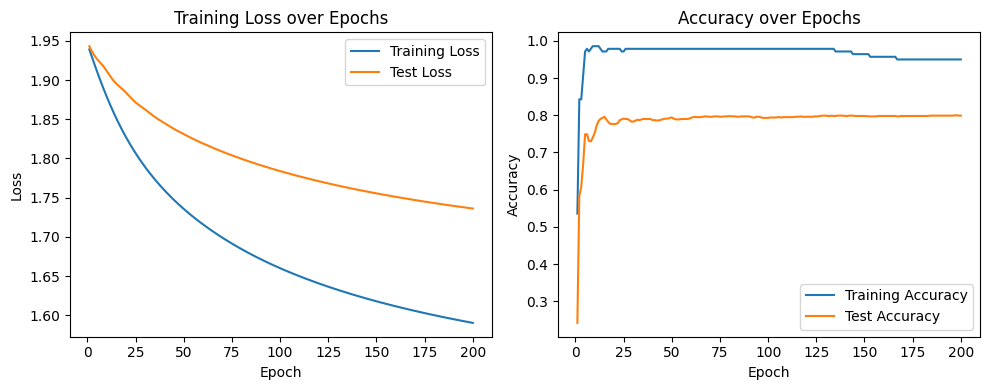

In [ ]:
import matplotlib.pyplot as plt

if optimizer_name == "adam":
    # Plotting the loss
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), losses, label='Training Loss')
    plt.plot(range(1, epochs + 1), test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()

    # Plotting accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
    plt.plot(range(1, epochs + 1), test_accuracies, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

else:
    # LBFGS final performance plot
    final_train_acc = train_accuracies[-1]
    final_test_acc = test_accuracies[-1]

    plt.figure(figsize=(6, 4))
    plt.bar(['Train', 'Test'], [final_train_acc, final_test_acc])
    plt.ylabel('Accuracy')
    plt.title('SGC Performance')
    plt.tight_layout()
    plt.show()